In [24]:
import pandas as pd
df = pd.read_csv("../data/ecommerce_sales_50k_15cols.csv")
df.head()



,OrderID,Date,CustomerID,Region,Product,Category,Units Sold,Unit Price,Discount (%),Payment Method,Shipping Method,Shipping Cost,Order Status,Customer Age,Customer Gender,Revenue,Profit
0,1,2024-11-16,8705,East,Product A,Sports,1,88,5,Debit Card,Standard,5,Delivered,43,Other,83.6,25.8
1,2,2024-05-04,6776,East,Product B,Books,3,88,0,Debit Card,Overnight,13,Returned,45,Female,264.0,92.6
2,3,2024-06-09,4669,North,Product D,Home,11,41,20,PayPal,Standard,9,Pending,23,Female,360.8,81.2
3,4,2024-04-30,8482,North,Product E,Home,19,66,15,Cash,Overnight,19,Cancelled,47,Female,1065.9,294.5
4,5,2024-06-15,5207,South,Product A,Sports,2,48,0,PayPal,Express,8,Delivered,65,Female,96.0,30.4


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          50000 non-null  int64  
 1   Date             50000 non-null  object 
 2   CustomerID       50000 non-null  int64  
 3   Region           50000 non-null  object 
 4   Product          50000 non-null  object 
 5   Category         50000 non-null  object 
 6   Units Sold       50000 non-null  int64  
 7   Unit Price       50000 non-null  int64  
 8   Discount (%)     50000 non-null  int64  
 9   Payment Method   50000 non-null  object 
 10  Shipping Method  50000 non-null  object 
 11  Shipping Cost    50000 non-null  int64  
 12  Order Status     50000 non-null  object 
 13  Customer Age     50000 non-null  int64  
 14  Customer Gender  50000 non-null  object 
 15  Revenue          50000 non-null  float64
 16  Profit           50000 non-null  float64
dtypes: float64(2

In [26]:
df.shape

(50000, 17)

In [27]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Region             0
Product            0
Category           0
Units Sold         0
Unit Price         0
Discount (%)       0
Payment Method     0
Shipping Method    0
Shipping Cost      0
Order Status       0
Customer Age       0
Customer Gender    0
Revenue            0
Profit             0
dtype: int64

In [28]:
df.nunique()

OrderID            50000
Date                 365
CustomerID          8960
Region                 4
Product                5
Category               5
Units Sold            20
Unit Price            81
Discount (%)           5
Payment Method         4
Shipping Method        3
Shipping Cost         16
Order Status           4
Customer Age          53
Customer Gender        3
Revenue             3323
Profit             11595
dtype: int64

In [29]:
df.describe()

,OrderID,CustomerID,Units Sold,Unit Price,Discount (%),Shipping Cost,Customer Age,Revenue,Profit
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,25000.500000,5496.536560,10.507920,60.123960,10.005000,12.52402,43.972540,568.726558,177.149646
std,14433.901067,2597.835047,5.767624,23.318561,7.068732,4.59404,15.312221,404.770190,144.567256
min,1.000000,1000.000000,1.000000,20.000000,0.000000,5.00000,18.000000,16.000000,-15.600000
25%,12500.750000,3242.000000,6.000000,40.000000,5.000000,9.00000,31.000000,244.000000,64.600000
50%,25000.500000,5507.000000,11.000000,60.000000,10.000000,13.00000,44.000000,476.850000,142.000000
75%,37500.250000,7738.250000,16.000000,80.000000,15.000000,16.00000,57.000000,820.000000,256.000000
max,50000.000000,9999.000000,20.000000,100.000000,20.000000,20.00000,70.000000,2000.000000,794.000000


In [30]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Region             0
Product            0
Category           0
Units Sold         0
Unit Price         0
Discount (%)       0
Payment Method     0
Shipping Method    0
Shipping Cost      0
Order Status       0
Customer Age       0
Customer Gender    0
Revenue            0
Profit             0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df[['Revenue','Profit','Units Sold']].describe()


,Revenue,Profit,Units Sold
count,50000.000000,50000.000000,50000.000000
mean,568.726558,177.149646,10.507920
std,404.770190,144.567256,5.767624
min,16.000000,-15.600000,1.000000
25%,244.000000,64.600000,6.000000
50%,476.850000,142.000000,11.000000
75%,820.000000,256.000000,16.000000
max,2000.000000,794.000000,20.000000


In [33]:
# Remove duplicates
df = df.drop_duplicates()

# Check missing values percentage
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage

OrderID            0.0
Date               0.0
CustomerID         0.0
Region             0.0
Product            0.0
Category           0.0
Units Sold         0.0
Unit Price         0.0
Discount (%)       0.0
Payment Method     0.0
Shipping Method    0.0
Shipping Cost      0.0
Order Status       0.0
Customer Age       0.0
Customer Gender    0.0
Revenue            0.0
Profit             0.0
dtype: float64

In [34]:
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()

total_revenue, total_profit


(np.float64(28436327.9), np.float64(8857482.3))

In [38]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [39]:
df['Date'].dtype

dtype('<M8[ns]')

In [40]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()

df.head()

,OrderID,Date,CustomerID,Region,Product,Category,Units Sold,Unit Price,Discount (%),Payment Method,...,Order Status,Customer Age,Customer Gender,Revenue,Profit,Year,Month,Quarter,Day,Day_Name
0,1,2024-11-16,8705,East,Product A,Sports,1,88,5,Debit Card,...,Delivered,43,Other,83.6,25.8,2024,11,4,16,Saturday
1,2,2024-05-04,6776,East,Product B,Books,3,88,0,Debit Card,...,Returned,45,Female,264.0,92.6,2024,5,2,4,Saturday
2,3,2024-06-09,4669,North,Product D,Home,11,41,20,PayPal,...,Pending,23,Female,360.8,81.2,2024,6,2,9,Sunday
3,4,2024-04-30,8482,North,Product E,Home,19,66,15,Cash,...,Cancelled,47,Female,1065.9,294.5,2024,4,2,30,Tuesday
4,5,2024-06-15,5207,South,Product A,Sports,2,48,0,PayPal,...,Delivered,65,Female,96.0,30.4,2024,6,2,15,Saturday


In [41]:
df['Date'].head()

0   2024-11-16
1   2024-05-04
2   2024-06-09
3   2024-04-30
4   2024-06-15
Name: Date, dtype: datetime64[ns]

In [43]:
#Create Profit Margin Feature
df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100

df[['Revenue','Profit','Profit_Margin']].head()

,Revenue,Profit,Profit_Margin
0,83.6,25.8,30.861244
1,264.0,92.6,35.075758
2,360.8,81.2,22.505543
3,1065.9,294.5,27.629234
4,96.0,30.4,31.666667


In [44]:
#Create Sales Time Features

df['Day_Name'] = df['Date'].dt.day_name()

df['Weekend'] = df['Date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

df.head()

,OrderID,Date,CustomerID,Region,Product,Category,Units Sold,Unit Price,Discount (%),Payment Method,...,Customer Gender,Revenue,Profit,Year,Month,Quarter,Day,Day_Name,Profit_Margin,Weekend
0,1,2024-11-16,8705,East,Product A,Sports,1,88,5,Debit Card,...,Other,83.6,25.8,2024,11,4,16,Saturday,30.861244,Weekend
1,2,2024-05-04,6776,East,Product B,Books,3,88,0,Debit Card,...,Female,264.0,92.6,2024,5,2,4,Saturday,35.075758,Weekend
2,3,2024-06-09,4669,North,Product D,Home,11,41,20,PayPal,...,Female,360.8,81.2,2024,6,2,9,Sunday,22.505543,Weekend
3,4,2024-04-30,8482,North,Product E,Home,19,66,15,Cash,...,Female,1065.9,294.5,2024,4,2,30,Tuesday,27.629234,Weekday
4,5,2024-06-15,5207,South,Product A,Sports,2,48,0,PayPal,...,Female,96.0,30.4,2024,6,2,15,Saturday,31.666667,Weekend


In [45]:
#Create Revenue Category


df['Sales_Category'] = pd.cut(
    df['Revenue'],
    bins=[0,1000,5000,10000,float('inf')],
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium'
    ]
)

df[['Revenue','Sales_Category']].head()

,Revenue,Sales_Category
0,83.6,Low Value
1,264.0,Low Value
2,360.8,Low Value
3,1065.9,Medium Value
4,96.0,Low Value


In [48]:
total_revenue = df['Revenue'].sum()

total_profit = df['Profit'].sum()

total_orders = df['OrderID'].nunique()

total_customers = df['CustomerID'].nunique()

avg_order_value = df['Revenue'].mean()

overall_profit_margin = (total_profit / total_revenue) * 100


print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)
print("Overall Profit Margin:", overall_profit_margin)

Total Revenue: 28436327.9
Total Profit: 8857482.3
Total Orders: 50000
Total Customers: 8960
Average Order Value: 568.726558
Overall Profit Margin: 31.148474342919645


In [49]:
#Category Performance Analysis

category_analysis = (
    df.groupby('Category')
    .agg(
        Total_Revenue=('Revenue','sum'),
        Total_Profit=('Profit','sum'),
        Total_Orders=('OrderID','count'),
        Average_Order_Value=('Revenue','mean')
    )
    .sort_values(
        by='Total_Revenue',
        ascending=False
    )
)

category_analysis

,Total_Revenue,Total_Profit,Total_Orders,Average_Order_Value
Category,,,,
Home,5738280.95,1786242.75,10038,571.655803
Books,5714640.35,1777137.55,10052,568.507794
Electronics,5690813.05,1774548.25,10004,568.853763
Sports,5679127.85,1769347.45,10000,567.912785
Apparel,5613465.70,1750206.30,9906,566.673299


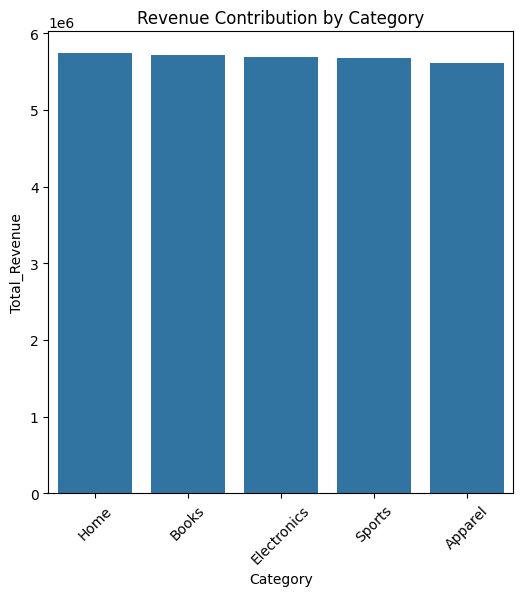

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

sns.barplot(
    data=category_analysis.reset_index(),
    x='Category',
    y='Total_Revenue'
)

plt.title("Revenue Contribution by Category")
plt.xticks(rotation=45)
plt.show()

In [55]:
#Product Performance


product_analysis = (
    df.groupby('Product')
    .agg(
        Revenue=('Revenue','sum'),
        Profit=('Profit','sum'),
        Units_Sold=('Units Sold','sum')
    )
    .sort_values(
        'Revenue',
        ascending=False
    )
)

product_analysis

,Revenue,Profit,Units_Sold
Product,,,
Product B,5763985.95,1799816.75,106313
Product A,5734817.70,1783091.70,105712
Product E,5694579.80,1776632.60,105642
Product C,5659082.00,1761499.00,103909
Product D,5583862.45,1736442.25,103820


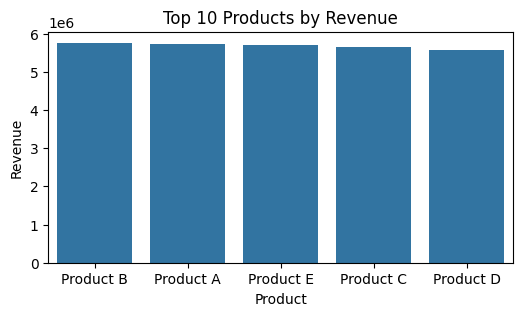

In [57]:
#Top 10 Products Chart
top_products = product_analysis.head(10)

plt.figure(figsize=(6,3))

sns.barplot(
    data=top_products.reset_index(),
    x='Product',
    y='Revenue'
)

plt.title("Top 10 Products by Revenue")
plt.show()

In [58]:
#Create Customer-Level Data
customer_analysis = (
    df.groupby('CustomerID')
    .agg(
        Last_Purchase=('Date','max'),
        Total_Orders=('OrderID','count'),
        Total_Revenue=('Revenue','sum'),
        Total_Profit=('Profit','sum')
    )
    .reset_index()
)

customer_analysis.head()

,CustomerID,Last_Purchase,Total_Orders,Total_Revenue,Total_Profit
0,1000,2024-11-24,4,3148.40,1064.60
1,1001,2024-10-25,3,1748.00,666.20
2,1002,2024-08-24,2,993.35,306.75
3,1003,2024-12-05,8,4639.80,1363.00
4,1004,2024-12-22,5,3178.40,1104.20


In [59]:
reference_date = df['Date'].max()

reference_date

Timestamp('2024-12-30 00:00:00')

In [60]:
#Days since last purchase:

customer_analysis['Recency'] = (
    reference_date - customer_analysis['Last_Purchase']
).dt.days

customer_analysis.head()

,CustomerID,Last_Purchase,Total_Orders,Total_Revenue,Total_Profit,Recency
0,1000,2024-11-24,4,3148.40,1064.60,36
1,1001,2024-10-25,3,1748.00,666.20,66
2,1002,2024-08-24,2,993.35,306.75,128
3,1003,2024-12-05,8,4639.80,1363.00,25
4,1004,2024-12-22,5,3178.40,1104.20,8


In [61]:
#Create RFM Table
rfm = customer_analysis[
    [
        'CustomerID',
        'Recency',
        'Total_Orders',
        'Total_Revenue'
    ]
]

rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]


rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,1000,36,4,3148.40
1,1001,66,3,1748.00
2,1002,128,2,993.35
3,1003,25,8,4639.80
4,1004,8,5,3178.40


In [63]:
#Create Customer Segments

rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)


rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)


rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

rfm.head()


C:\Users\HPP\AppData\Local\Temp\ipykernel_18440\984283524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['R_Score'] = pd.qcut(


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,1000,36,4,3148.40,3,1,3
1,1001,66,3,1748.00,2,1,1
2,1002,128,2,993.35,1,1,1
3,1003,25,8,4639.80,3,4,4
4,1004,8,5,3178.40,4,2,3


In [64]:
# Create Overall RFM Score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int)
    +
    rfm['F_Score'].astype(int)
    +
    rfm['M_Score'].astype(int)
)


rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1000,36,4,3148.40,3,1,3,7
1,1001,66,3,1748.00,2,1,1,4
2,1002,128,2,993.35,1,1,1,3
3,1003,25,8,4639.80,3,4,4,11
4,1004,8,5,3178.40,4,2,3,9


In [65]:
#Customer Segment Classification
def segment_customer(score):

    if score >= 10:
        return "Premium Customer"

    elif score >= 7:
        return "Loyal Customer"

    elif score >= 5:
        return "Regular Customer"

    else:
        return "Low Value Customer"



rfm['Customer_Segment'] = rfm['RFM_Score'].apply(segment_customer)


rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,1000,36,4,3148.40,3,1,3,7,Loyal Customer
1,1001,66,3,1748.00,2,1,1,4,Low Value Customer
2,1002,128,2,993.35,1,1,1,3,Low Value Customer
3,1003,25,8,4639.80,3,4,4,11,Premium Customer
4,1004,8,5,3178.40,4,2,3,9,Loyal Customer


In [66]:
#Segment Distribution
segment_count = (
    rfm['Customer_Segment']
    .value_counts()
)

segment_count



Customer_Segment
Loyal Customer        3158
Premium Customer      2430
Regular Customer      1928
Low Value Customer    1444
Name: count, dtype: int64

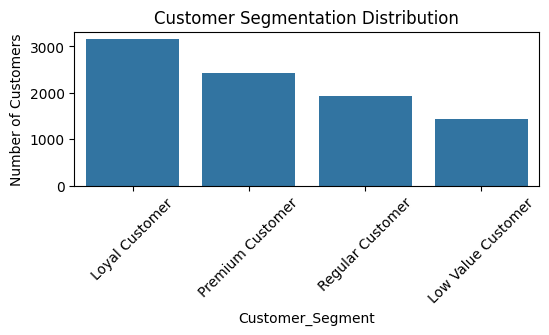

In [68]:
#Visualization:

plt.figure(figsize=(6,2))

sns.barplot(
    x=segment_count.index,
    y=segment_count.values
)

plt.title("Customer Segmentation Distribution")
plt.xticks(rotation=45)
plt.ylabel("Number of Customers")

plt.show()


In [69]:
#Revenue Contribution by Segment

segment_revenue = (
    rfm.groupby('Customer_Segment')
    ['Monetary']
    .sum()
    .sort_values(
        ascending=False
    )
)

segment_revenue



Customer_Segment
Premium Customer      12016228.95
Loyal Customer        10395216.45
Regular Customer       4062808.35
Low Value Customer     1962074.15
Name: Monetary, dtype: float64

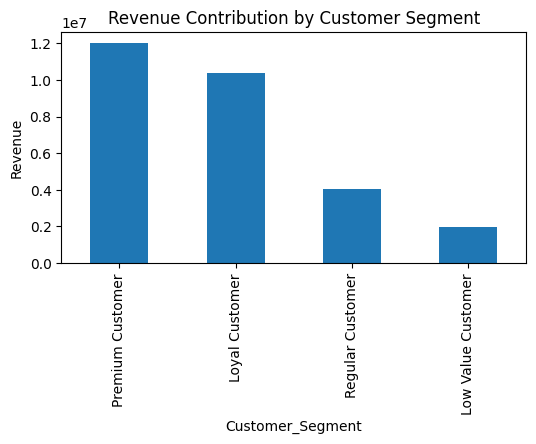

In [71]:
#Plot

plt.figure(figsize=(6,3))

segment_revenue.plot(
    kind='bar'
)

plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Revenue")

plt.show()